In [4]:
!pip install -q pandas numpy scikit-learn joblib matplotlib seaborn

In [5]:
# Import Pandas for loading and manipulating the dataset
import pandas as pd

# Import NumPy for numerical operations and array handling
import numpy as np

# Import Joblib to save and load the trained machine learning model
import joblib

# Import Matplotlib for creating charts and visualizations
import matplotlib.pyplot as plt

# Import Seaborn for creating statistical visualizations
import seaborn as sns

# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import ColumnTransformer to apply different preprocessing steps
# to selected columns
from sklearn.compose import ColumnTransformer

# Import Pipeline to combine preprocessing and model training steps
from sklearn.pipeline import Pipeline

# Import SimpleImputer to handle missing values in the dataset
from sklearn.impute import SimpleImputer

# Import StandardScaler to standardize numerical features
# OneHotEncoder is used to convert categorical values into numerical form
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import RandomForestClassifier to classify faculty burnout risk
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics to measure model performance
from sklearn.metrics import (
    # Calculate the percentage of correct predictions
    accuracy_score,

    # Display precision, recall, F1-score, and support for each class
    classification_report,

    # Show the number of correct and incorrect predictions
    confusion_matrix,

    # Measure how well the model separates different classes
    roc_auc_score
)

In [6]:
# Load the faculty workload dataset from the CSV file into a Pandas DataFrame
df = pd.read_csv("/content/faculty_workload_dataset.csv")

# Display the first five rows of the dataset
# This helps verify that the data was loaded correctly
df.head()

,Faculty_ID,Teaching_Hours,Advising_Students,Committee_Count,Research_Hours,Admin_Hours,Semester_Progress,Historical_Leave_Days,Workload_Score,Pressure_Score,Burnout_Risk
0,FAC_001,14,23,7,10,4,0.07,8,0.487698,0.365853,Low
1,FAC_002,27,12,6,4,14,0.24,4,0.572619,0.441382,Medium
2,FAC_003,22,29,3,12,15,0.06,3,0.673810,0.410066,Medium
3,FAC_004,18,6,5,7,9,0.67,1,0.388095,0.392513,Low
4,FAC_005,15,2,6,3,14,0.90,0,0.356746,0.411462,Medium


In [7]:
# Define the input features used by the machine learning model
feature_columns = [
    "Teaching_Hours",          # Number of hours spent teaching
    "Advising_Students",       # Number of students guided by the faculty
    "Committee_Count",         # Number of committees handled
    "Research_Hours",          # Hours spent on research activities
    "Admin_Hours",             # Hours spent on administrative work
    "Semester_Progress",       # Percentage of semester completed
    "Historical_Leave_Days"    # Number of leave days taken previously
]

# Define the target column that the model needs to predict
target_column = "Burnout_Risk"

# Select the input feature columns from the dataset
# X contains the information used to make predictions
X = df[feature_columns]

# Select the target column from the dataset
# y contains the actual burnout-risk labels: Low, Medium, or High
y = df[target_column]

In [8]:
# Split the input features and target labels into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Input features
    y,                  # Target labels
    test_size=0.20,     # Use 20% of the data for testing
    random_state=42,   # Ensures the same split every time
    stratify=y         # Maintains the same class distribution in both sets
)

# Display the number of records used for training
print("Training records:", X_train.shape[0])

# Display the number of records used for testing
print("Testing records:", X_test.shape[0])

Training records: 400
Testing records: 100


In [9]:
# Store all input feature names in the numeric_features variable
# All features in this project are numerical
numeric_features = feature_columns

# Create a preprocessing pipeline for numerical features
numeric_transformer = Pipeline(
    steps=[
        # Replace missing values with the median of each column
        ("imputer", SimpleImputer(strategy="median")),

        # Standardize the numerical features to a common scale
        ("scaler", StandardScaler())
    ]
)

# Create a ColumnTransformer to apply preprocessing
# to the selected numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        # "num" is the name of this transformation
        # numeric_transformer contains imputation and scaling steps
        # numeric_features specifies the columns to preprocess
        ("num", numeric_transformer, numeric_features)
    ]
)

In [10]:
# Create a Random Forest classification model
# The model will predict faculty burnout-risk categories
random_forest_model = RandomForestClassifier(
    # Number of decision trees used in the Random Forest
    n_estimators=150,

    # Maximum depth allowed for each decision tree
    # This helps control model complexity and reduce overfitting
    max_depth=8,

    # Ensures the same results whenever the model is trained
    random_state=42,

    # Gives more importance to classes with fewer records
    # This helps handle imbalanced burnout-risk categories
    class_weight="balanced"
)

In [11]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest_model)
    ]
)

In [12]:
model_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [13]:
y_pred = model_pipeline.predict(X_test)

y_pred[:10]

array(['Medium', 'Medium', 'Medium', 'Medium', 'Low', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium'], dtype=object)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Accuracy: 0.7800
Accuracy Percentage: 78.00%


In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.53      0.64        15
         Low       0.80      0.55      0.65        22
      Medium       0.77      0.92      0.84        63

    accuracy                           0.78       100
   macro avg       0.79      0.67      0.71       100
weighted avg       0.78      0.78      0.77       100



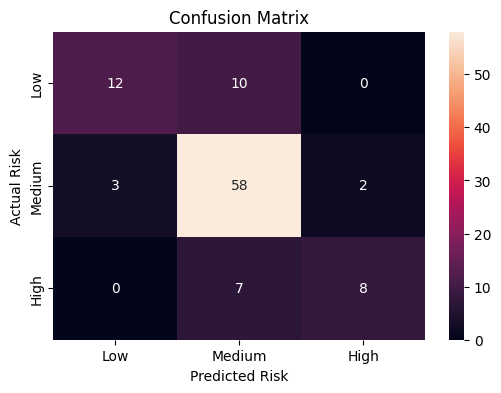

In [16]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Calculate the confusion matrix
# The confusion matrix shows the number of correct and incorrect predictions made by the classification model
# compared to the actual outcomes (target values) in the test data.
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

# Set up the figure size for the plot
plt.figure(figsize=(6, 4))

# Create a heatmap to visualize the confusion matrix
# annot=True displays the numerical values on the heatmap cells
# fmt="d" formats the annotations as integers
# xticklabels and yticklabels set the labels for the x and y axes corresponding to the classes
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

# Add labels and title to the plot
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("Confusion Matrix")
# Display the plot
plt.show()

In [17]:
# Convert the actual test labels into one-hot encoded format
# This is required for calculating multiclass ROC-AUC
y_test_encoded = pd.get_dummies(
    y_test
).reindex(
    # Arrange the encoded columns in the same order as the model's classes
    columns=model_pipeline.classes_,

    # Add any missing class column with a value of 0
    fill_value=0
)

# Predict the probability of each burnout-risk class for the test data
# The output contains probabilities for Low, Medium, and High classes
y_probability = model_pipeline.predict_proba(X_test)

# Calculate the weighted ROC-AUC score
# multi_class="ovr" uses the One-vs-Rest strategy for multiclass classification
# average="weighted" gives more importance to classes with more test samples
roc_auc = roc_auc_score(
    y_test_encoded,
    y_probability,
    multi_class="ovr",
    average="weighted"
)

# Display the calculated Weighted ROC-AUC score with four decimal places
print(f"Weighted ROC-AUC: {roc_auc:.4f}")

Weighted ROC-AUC: 0.9323


In [18]:
classifier = model_pipeline.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Teaching_Hours,0.294017
5,Semester_Progress,0.227480
6,Historical_Leave_Days,0.165805
1,Advising_Students,0.083881
3,Research_Hours,0.081974
4,Admin_Hours,0.078805
2,Committee_Count,0.068037


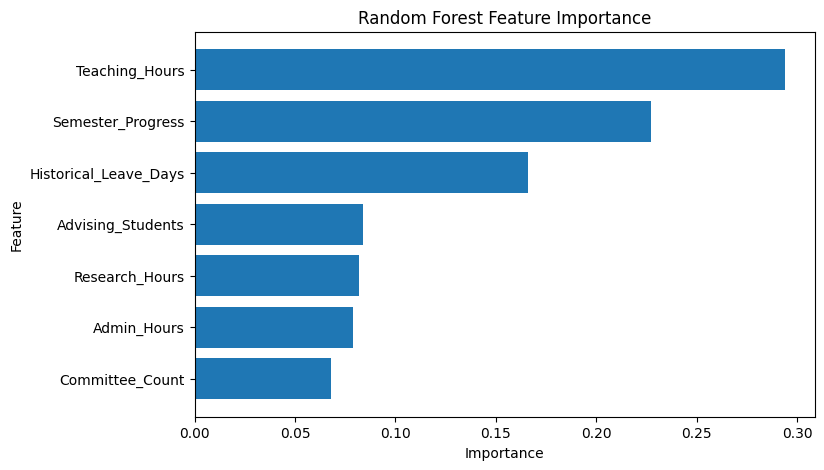

In [19]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [20]:
model_path = "/content/faculty_burnout_model_pipeline.pkl"

joblib.dump(
    model_pipeline,
    model_path
)

print(f"Model pipeline saved at: {model_path}")

Model pipeline saved at: /content/faculty_burnout_model_pipeline.pkl


In [23]:
from google.colab import files

files.download("/content/faculty_burnout_model_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>